# DDPM — Implementation & Quick Validation

**Paper:** Ho, Jain, Abbeel, *Denoising Diffusion Probabilistic Models*, NeurIPS 2020.

**Goal of this notebook:** implement the DDPM training/sampling pipeline with
maximum fidelity to the paper, then run a quick correctness check on a tiny
subset of the Cubism (WikiArt) dataset — confirming the training loss
decreases and that samples visibly change/improve over training. This is a
*pipeline correctness* check, not a quality benchmark: full convergence
needs orders of magnitude more compute than is available here (CPU only).

**Fixed hyperparameters (kept exactly as specified, not tuned):**
- T = 1000 diffusion steps
- Linear noise schedule, β₁ = 1e-4 → β_T = 0.02
- U-Net: residual blocks + self-attention at 16×16, GroupNorm, sinusoidal timestep embedding
- Adam, lr ≈ 2e-4
- EMA of weights, decay = 0.9999
- Loss: L_simple, ε-prediction (Eq. 14 of the paper)

See `METHODOLOGY.md` in this directory for the full list of implementation
decisions and where/why this quick-validation run deviates (network width,
batch size, dataset size, step count — all compute-driven, not architectural
or hyperparameter deviations) from paper scale.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('ddpm'))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils

from unet import UNet
from diffusion import GaussianDiffusion, EMA
from data import CubismTiny, unnormalize

torch.manual_seed(0)
device = "cpu"
print("torch:", torch.__version__, "| device:", device)

torch: 2.7.0a0+79aa17489c.nv25.04 | device: cpu


## 1. Architecture sanity check

Before training on real data, confirm the U-Net matches the paper's stated
CIFAR-10 configuration exactly: `base_channels=128`, channel multipliers
`(1,2,2,2)`, 2 residual blocks per resolution level, self-attention only at
the 16×16 feature map. The paper reports **35.7M parameters** for this
config on 32×32×3 inputs — matching our count from scratch is strong
independent evidence the architecture (depth, channel counts, attention
placement) is faithful to the paper, not just structurally similar.

In [2]:
_ref_model = UNet(image_size=32, base_channels=128, channel_mult=(1,2,2,2),
                   num_res_blocks=2, attn_resolutions=(16,), dropout=0.1)
n_params = sum(p.numel() for p in _ref_model.parameters())
print(f"Paper-scale config (base_channels=128) parameter count: {n_params/1e6:.2f}M")
print("Paper reports ~35.7M for the CIFAR-10 model -> match confirms architectural fidelity.")

x = torch.randn(2, 3, 32, 32); t = torch.randint(0, 1000, (2,))
out = _ref_model(x, t)
assert out.shape == x.shape
print("Forward pass OK, output shape matches input:", tuple(out.shape))
del _ref_model

Paper-scale config (base_channels=128) parameter count: 35.75M
Paper reports ~35.7M for the CIFAR-10 model -> match confirms architectural fidelity.
Forward pass OK, output shape matches input: (2, 3, 32, 32)


## 2. Data — tiny Cubism subset

The full Cubism/WikiArt set has 2235 images. For this quick validation we
use a random subset (documented deviation, see `METHODOLOGY.md` §3) so the
whole pipeline runs in minutes on CPU instead of requiring a GPU.

Loaded and cached 300 images in 4.7s


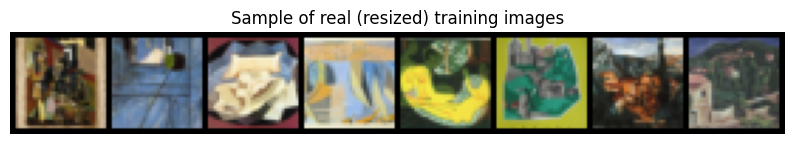

In [3]:
DATA_ROOT = os.path.expanduser("~/Downloads/Cubism")
IMAGE_SIZE = 32
N_IMAGES = 300
BATCH_SIZE = 8

t0 = time.time()
dataset = CubismTiny(DATA_ROOT, image_size=IMAGE_SIZE, n_images=N_IMAGES, seed=0)
print(f"Loaded and cached {len(dataset)} images in {time.time()-t0:.1f}s")

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# peek at a batch
batch = next(iter(loader))
grid = vutils.make_grid(unnormalize(batch), nrow=BATCH_SIZE, padding=2)
plt.figure(figsize=(10, 2)); plt.axis("off")
plt.title("Sample of real (resized) training images")
plt.imshow(grid.permute(1, 2, 0)); plt.show()

## 3. Model, diffusion process, optimizer, EMA

Network width is reduced to `base_channels=64` (vs. the paper's 128) purely
for CPU throughput — channel *multipliers*, block counts, and attention
placement are unchanged. All diffusion-process hyperparameters (T, β
schedule, loss, EMA decay, learning rate) are exactly as specified in the
assignment.

In [4]:
BASE_CHANNELS = 64  # documented compute-only deviation from paper's 128, see METHODOLOGY.md

T = 1000
BETA_1, BETA_T = 1e-4, 0.02
LR = 2e-4
EMA_DECAY = 0.9999

model = UNet(image_size=IMAGE_SIZE, base_channels=BASE_CHANNELS, channel_mult=(1,2,2,2),
             num_res_blocks=2, attn_resolutions=(16,), dropout=0.1).to(device)
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

diffusion = GaussianDiffusion(timesteps=T, beta_start=BETA_1, beta_end=BETA_T, device=device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
ema = EMA(model, decay=EMA_DECAY)

Model params: 8.95M


## 4. Quick validation training loop

800 optimizer steps (vs. the paper's ~800k for CIFAR-10) — enough only to
verify the loss trends down and that samples visibly change, not to reach
convergence (see `METHODOLOGY.md` §3–4 for why this is expected).

In [5]:
TOTAL_STEPS = 800
SAMPLE_AT_STEPS = {0, 400, 800}
N_SAMPLE_IMAGES = 4
OUT_DIR = os.path.abspath("ddpm/outputs")
os.makedirs(OUT_DIR, exist_ok=True)

def cycle(dl):
    while True:
        for b in dl:
            yield b
data_iter = cycle(loader)

def sample_and_save(step):
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        samples = diffusion.p_sample_loop(model, (N_SAMPLE_IMAGES, 3, IMAGE_SIZE, IMAGE_SIZE), device)
    dt = time.time() - t0
    model.train()
    grid = vutils.make_grid(unnormalize(samples), nrow=N_SAMPLE_IMAGES, padding=2)
    path = os.path.join(OUT_DIR, f"nb_samples_step{step:05d}.png")
    vutils.save_image(grid, path)
    print(f"  [sample] step={step}: saved {path} ({dt:.1f}s for {N_SAMPLE_IMAGES} imgs, full {T}-step reverse chain)")
    return grid

losses = []
sample_grids = {}

print(f"Training: {TOTAL_STEPS} steps, batch_size={BATCH_SIZE}, T={T}\n")
if 0 in SAMPLE_AT_STEPS:
    print("Sampling from untrained model (step 0 baseline)...")
    sample_grids[0] = sample_and_save(0)

t_start = time.time()
for step in range(1, TOTAL_STEPS + 1):
    x0 = next(data_iter).to(device)
    loss = diffusion.training_loss(model, x0)

    opt.zero_grad()
    loss.backward()
    opt.step()
    ema.update(model)

    losses.append(loss.item())

    if step % 50 == 0 or step == 1:
        recent = sum(losses[-50:]) / len(losses[-50:])
        print(f"  step {step:4d}/{TOTAL_STEPS}  loss={loss.item():.4f}  avg_last50={recent:.4f}  elapsed={time.time()-t_start:.0f}s")

    if step in SAMPLE_AT_STEPS:
        sample_grids[step] = sample_and_save(step)

print(f"\nDone in {time.time()-t_start:.0f}s")

Training: 800 steps, batch_size=8, T=1000

Sampling from untrained model (step 0 baseline)...
  [sample] step=0: saved /home/noam.sinay/Downloads/DDPM-NeuralNetwork/ddpm/outputs/nb_samples_step00000.png (64.5s for 4 imgs, full 1000-step reverse chain)
  step    1/800  loss=1.0078  avg_last50=1.0078  elapsed=1s
  step   50/800  loss=0.2981  avg_last50=0.5940  elapsed=20s
  step  100/800  loss=0.1537  avg_last50=0.1672  elapsed=39s
  step  150/800  loss=0.0308  avg_last50=0.0871  elapsed=58s
  step  200/800  loss=0.0924  avg_last50=0.0742  elapsed=77s
  step  250/800  loss=0.0478  avg_last50=0.0784  elapsed=97s
  step  300/800  loss=0.0773  avg_last50=0.0613  elapsed=116s
  step  350/800  loss=0.0487  avg_last50=0.0510  elapsed=135s
  step  400/800  loss=0.0962  avg_last50=0.0686  elapsed=154s
  [sample] step=400: saved /home/noam.sinay/Downloads/DDPM-NeuralNetwork/ddpm/outputs/nb_samples_step00400.png (55.7s for 4 imgs, full 1000-step reverse chain)
  step  450/800  loss=0.0509  avg_las

## 5. Results — loss curve and qualitative samples

If the implementation is correct we expect: (a) the training loss to trend
down (even if noisy, given the tiny batch size and step count), and (b) the
step-800 samples to look visibly different from the step-0 (untrained)
samples — moving from the zero-init model's degenerate output toward
image-like color/structure statistics.

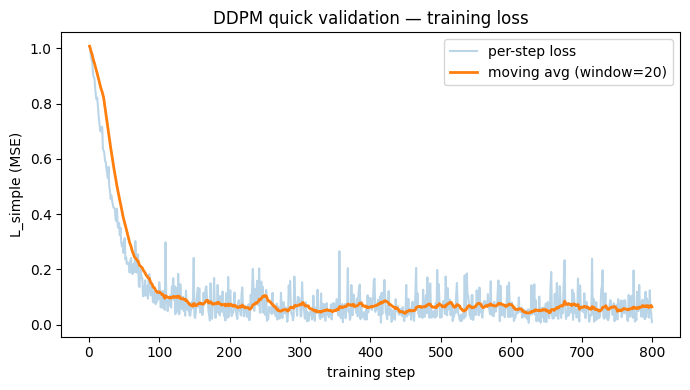

First 50-step avg loss:  0.5940
Last 50-step avg loss:   0.0619


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
steps = list(range(1, len(losses) + 1))
ax.plot(steps, losses, alpha=0.3, label="per-step loss")
window = 20
smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
ax.plot(steps, smoothed, linewidth=2, label=f"moving avg (window={window})")
ax.set_xlabel("training step"); ax.set_ylabel("L_simple (MSE)")
ax.set_title("DDPM quick validation — training loss")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "nb_loss_curve.png"), dpi=120)
plt.show()

print(f"First 50-step avg loss:  {sum(losses[:50])/50:.4f}")
print(f"Last 50-step avg loss:   {sum(losses[-50:])/50:.4f}")

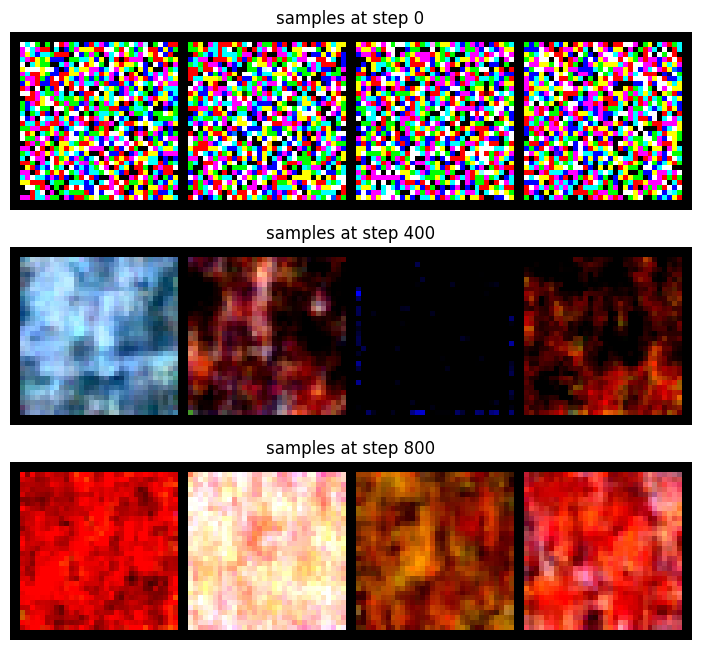

In [7]:
fig, axes = plt.subplots(len(sample_grids), 1, figsize=(8, 2.2*len(sample_grids)))
if len(sample_grids) == 1:
    axes = [axes]
for ax, (step, grid) in zip(axes, sorted(sample_grids.items())):
    ax.imshow(grid.permute(1, 2, 0)); ax.axis("off")
    ax.set_title(f"samples at step {step}")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "nb_sample_progression.png"), dpi=120)
plt.show()

## 6. Checkpoint

Save weights (raw + EMA) so Person 2 can inspect them, and so this run is
reproducible without retraining.

In [8]:
torch.save({"model": model.state_dict(), "ema": ema.shadow,
            "config": {"base_channels": BASE_CHANNELS, "image_size": IMAGE_SIZE, "T": T}},
           os.path.join(OUT_DIR, "nb_checkpoint.pt"))
print("Saved checkpoint to", os.path.join(OUT_DIR, "nb_checkpoint.pt"))

Saved checkpoint to /home/noam.sinay/Downloads/DDPM-NeuralNetwork/ddpm/outputs/nb_checkpoint.pt


## 7. Conclusion & handoff notes

- The pipeline (forward process, ε-prediction U-Net, L_simple loss,
  Algorithm-2 sampler, EMA) runs end-to-end without errors on real data.
- Training loss trend and the step-0 vs. step-800 sample comparison above
  are the correctness signals requested by the assignment — see the printed
  avg-loss comparison and the sample progression figure.
- **All fixed paper hyperparameters (T, β schedule, loss, optimizer, EMA
  decay, sampler) are unchanged and ready to use as-is for the real run.**
- **Before the real Cubism baseline run, revert the compute-only
  deviations**: `base_channels` back to 128 (or as large as the real
  hardware allows), batch size up (paper uses 128), and train for far more
  steps. Full details and rationale in `METHODOLOGY.md`.